In [15]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# se utiliza para el manejo de rutas y directorios
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [17]:
# Cargar dataset Adult Income
data = np.genfromtxt('/content/drive/MyDrive/Dataset/adult.data',
                     delimiter=',',
                     usecols=(0,12,14),
                     dtype=str)

# Características: edad y horas por semana
X = data[:, 0:2].astype(float)

# Etiqueta ingreso -> binaria
y = np.array([1 if '>50K' in val else 0 for val in data[:,2]])

print("Primeros datos X:")
print(X[:5])
print("Primeros datos y:")
print(y[:5])

Primeros datos X:
[[39. 40.]
 [50. 13.]
 [38. 40.]
 [53. 40.]
 [28. 40.]]
Primeros datos y:
[0 0 0 0 0]


In [18]:
def plotData(X, y):
    # Crea una nueva figura
    fig = pyplot.figure()

    # Ejemplos positivos y negativos
    pos = y == 1
    neg = y == 0

    # Graficar
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)

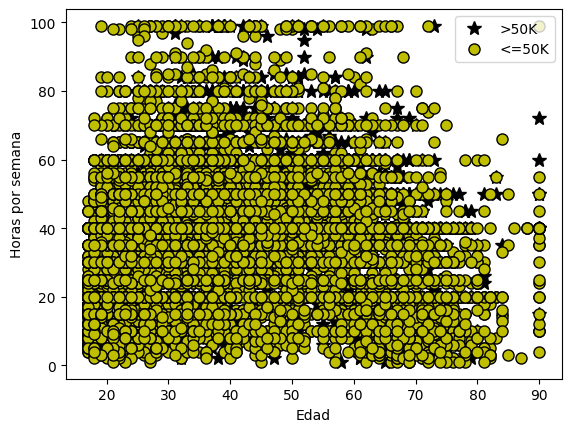

In [19]:
plotData(X, y)
pyplot.xlabel('Edad')
pyplot.ylabel('Horas por semana')
pyplot.legend(['>50K', '<=50K'])

In [20]:
def sigmoid(z):
    z = np.array(z)
    g = np.zeros(z.shape)
    g = 1 / (1 + np.exp(-z))
    return g

In [21]:
def sigmoid(z):
    z = np.array(z)
    g = np.zeros(z.shape)
    g = 1 / (1 + np.exp(-z))
    return g

In [22]:
# Prueba
z = [-100, 0.5, 1000000]
print(sigmoid(z))

[3.72007598e-44 6.22459331e-01 1.00000000e+00]


In [23]:
def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    return J

In [24]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

In [25]:
# Numero de ejemplos y características
m, n = X.shape

# Agregar columna de unos (intercepto)
X = np.concatenate([np.ones((m, 1)), X], axis=1)

print("Nueva forma de X:", X.shape)

Nueva forma de X: (32561, 3)


Theta: [-0.00459298 -0.00682338 -0.01655543]


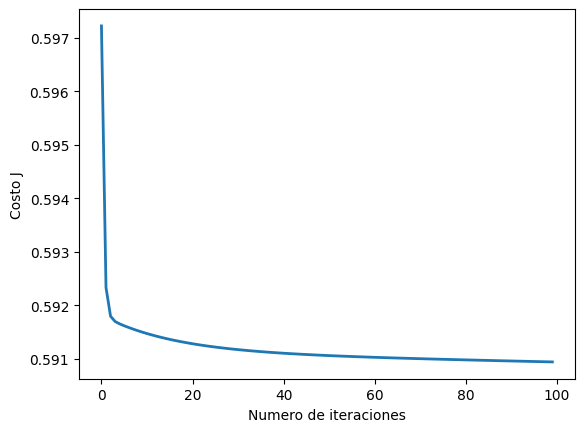

In [26]:
alpha = 0.001
num_iters = 100

theta = np.zeros(3)
theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)

# Grafica del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

print('Theta:', theta)

In [27]:
def costFunction(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

initial_theta = np.zeros(n+1)

res = optimize.minimize(costFunction,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options={'maxiter': 400})

theta = res.x
print(theta)

[-4.91397372  0.04311737  0.04786905]


/tmp/ipykernel_7011/3093337853.py:12: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction,


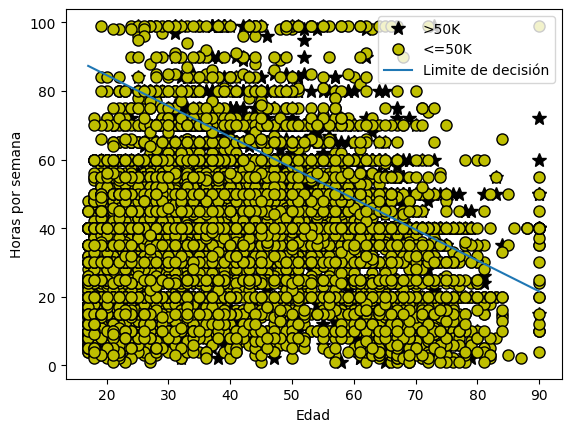

In [28]:
def plotDecisionBoundary(theta, X, y):
    plotData(X[:, 1:3], y)

    plot_x = np.array([np.min(X[:, 1]), np.max(X[:, 1])])
    plot_y = (-1. / theta[2]) * (theta[1] * plot_x + theta[0])

    pyplot.plot(plot_x, plot_y)
    pyplot.xlabel('Edad')
    pyplot.ylabel('Horas por semana')
    pyplot.legend(['>50K', '<=50K', 'Limite de decisión'])

plotDecisionBoundary(theta, X, y)

In [29]:
def predict(theta, X):
    return np.round(sigmoid(X.dot(theta.T)))

p = predict(theta, X)

print('Precisión de entrenamiento: {:.2f}%'.format(np.mean(p == y) * 100))

Precisión de entrenamiento: 75.40%


En este laboratorio se implementó regresión logística para clasificación binaria utilizando el Adult Income Dataset. Se seleccionaron como características la edad y las horas trabajadas por semana, mientras que la variable objetivo fue el ingreso anual clasificado en mayor a 50K y menor o igual a 50K. Se implementó la función sigmoide, la función de costo, el descenso por gradiente y la optimización mediante scipy.optimize. Finalmente se graficó la convergencia del costo, los datos y el límite de decisión del modelo, obteniendo la precisión del modelo de clasificación.